##### Streaming
https://docs.langchain.com/oss/python/langgraph/streaming

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.environ.get("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.environ.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_STREAM_PROJECT_NAME"] = os.environ.get(
    "LANGCHAIN_STREAM_PROJECT_NAME"
)

In [4]:
# test llm call
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

llm = ChatGroq(model="qwen/qwen3-32b")
response = llm.invoke([HumanMessage(content=f"what is the recent IPL news")])
response.content

"<think>\nOkay, the user is asking for the latest news about the Indian Premier League (IPL). Let me start by recalling the most recent developments. First, the 2024 season has already started, right? The auction was in February, so I should mention which teams picked which players. For example, Gujarat Giants added some big names like Ishan Kishan as their captain. Also, there was a rule change about the overseas player limit increasing to 2. \n\nWait, the user might also want to know about the schedule. The IPL usually runs from March to May, so with the 2024 season ongoing, I should note the dates and maybe the venues. There's a new team, Gujarat, making their debut. I should highlight that. \n\nAnother point is the captaincy changes. Teams like Delhi Capitals have changed their captains, which could affect their strategy. Plus, the fan engagement initiatives, like the cheer squad and the new anthem, are part of the IPL's efforts to boost viewership. \n\nI should check if there are 

In [8]:
# create schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

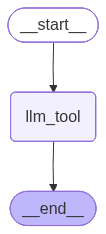

In [11]:
# configure the graph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


# creating a chatbot node
def llm_tool(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)

builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

# compile graph with In-Memory saver...

from langgraph.checkpoint.memory import InMemorySaver # short-term memory (RAM)
memory = InMemorySaver()
graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [12]:
## specify the thread
config = {"configurable": {"thread_id": "1"}}
messages = graph_memory.invoke({"messages": HumanMessage(content="What is 5 plus 5")}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 5 plus 5
================================== Ai Message ==================================

<think>
Okay, the user is asking "What is 5 plus 5". Let me think. First, I need to make sure I understand the question correctly. It's a simple arithmetic problem. Adding 5 and 5 together. In basic math, 5 plus 5 equals 10. But wait, maybe they want a detailed explanation? Let me check. The user might be a child learning addition, so explaining it step by step could be helpful. Let me break it down. If you have 5 apples and someone gives you 5 more apples, how many apples do you have in total? That's 5 + 5. Counting them out: 5, 6, 7, 8, 9, 10. So the answer is 10. Alternatively, using fingers: holding up 5 fingers on one hand and 5 on the other makes 10 fingers total. I should also consider if there's any trick here, like in a different base system. But the question doesn't specify a base, so it's safe to 

In [13]:
messages = graph_memory.invoke({"messages": HumanMessage(content="divide that by 5")}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 5 plus 5
================================== Ai Message ==================================

<think>
Okay, the user is asking "What is 5 plus 5". Let me think. First, I need to make sure I understand the question correctly. It's a simple arithmetic problem. Adding 5 and 5 together. In basic math, 5 plus 5 equals 10. But wait, maybe they want a detailed explanation? Let me check. The user might be a child learning addition, so explaining it step by step could be helpful. Let me break it down. If you have 5 apples and someone gives you 5 more apples, how many apples do you have in total? That's 5 + 5. Counting them out: 5, 6, 7, 8, 9, 10. So the answer is 10. Alternatively, using fingers: holding up 5 fingers on one hand and 5 on the other makes 10 fingers total. I should also consider if there's any trick here, like in a different base system. But the question doesn't specify a base, so it's safe to 

##### .stream() method with updates and values as parameters

In [17]:
## create a new thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_memory.stream({'messages': "Hi my name is dennis and i like basketball"}, config, stream_mode="updates"):
    print(chunk)

{'llm_tool': {'messages': [AIMessage(content="<think>\nOkay, the user introduced himself again as Dennis and mentioned he likes basketball. I need to respond appropriately.\n\nLooking back at the history, I had already greeted him, asked about his position and what he likes. Now, he's repeating his introduction. Maybe he's testing or wants to start a new conversation, but the system might have reset the context.\n\nI should acknowledge his introduction again. Maybe he's not aware he already said it. Need to be friendly and invite him to share more. Ask about his favorite team, position, or something else related to basketball. Keep the tone positive and engaging. Avoid redundancy but provide new questions to encourage interaction. Make sure the response is concise and helpful. Also, check for any possible typos or if he meant something else. But since it's the same message, just respond as if meeting him for the first time again. Maybe he wants to continue the conversation in a new thr

In [18]:
for chunk in graph_memory.stream({'messages': "i also like cricket"}, config, stream_mode="updates"):
    print(chunk)

{'llm_tool': {'messages': [AIMessage(content="<think>\nOkay, let me see. The user mentioned they like basketball and now they added they also like cricket. So I need to acknowledge both. The user's name is Dennis. I should make sure to address him by name again to keep it personal.\n\nFirst, I should express enthusiasm for both sports. Maybe use emojis related to both basketball and cricket. The user might be interested in discussing either sport, so I should invite them to share more about either one. Perhaps ask about favorite teams, players, or memorable moments in both sports. Also, check if they play or just watch. Maybe mention common aspects, like teamwork or strategy, to connect both sports and show understanding. Keep the tone friendly and encouraging. Let them know I'm here to chat about either sport. Avoid any complex jargon. Keep it simple and conversational. Make sure to end with an open question to prompt further interaction.\n</think>\n\nHey Dennis! 🏀🏏 Awesome—cricket is

In [20]:
for chunk in graph_memory.stream({'messages': "I love sports"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is dennis and i like basketball', additional_kwargs={}, response_metadata={}, id='6859aabd-ab50-45c4-bd8c-ccf4722f711c'), AIMessage(content="<think>\nOkay, Dennis has introduced himself and mentioned he likes basketball. I should acknowledge his introduction and express enthusiasm about his interest in basketball. Let's keep the response friendly and engaging, asking open-ended questions about basketball to encourage conversation. Maybe ask about his favorite team, position, or what he enjoys most about playing basketball. Keep it light and positive to build rapport.\n</think>\n\nHi Dennis! Nice to meet you. 🏀 I love that you're into basketball—it's such an exciting sport! Do you play any particular position, or do you just enjoy watching games? I'd be curious to hear what you like most about the game!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 18, 'total_tokens': 149, 'completion_

##### Note: 
- when 'update' was passed in the params, it streamed only the AI message which is the state after the latest node(LLM)
- where as when 'values' was passed in the params, it streamed the Human message and the AI Message which is nothing but streaming the full state of graph after each node is called.

#### astream method - captures all the events similar to applog

We often want to stream more thant the graph state
Each event is a dict with a few keys
- event : This is the type of event that is being emitted
- name : This is the name of the event
- data : This is the data associated with the event
- metadata : contains the node emitting the event

In [21]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_memory.astream_events({'messages': "Hi my name is dennis and i like basketball"}, config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is dennis and i like basketball'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019dcb14-60af-76c1-86c1-55cdc548be24', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is dennis and i like basketball', additional_kwargs={}, response_metadata={}, id='5d4aa351-186e-4b65-bd7b-98c42720d6f9')]}}, 'name': 'llm_tool', 'tags': ['graph:step:1'], 'run_id': '019dcb14-60b4-7773-b164-122db4a20379', 'metadata': {'thread_id': '3', 'langgraph_step': 1, 'langgraph_node': 'llm_tool', 'langgraph_triggers': ('branch:to:llm_tool',), 'langgraph_path': ('__pregel_pull', 'llm_tool'), 'langgraph_checkpoint_ns': 'llm_tool:0d31a520-9ca5-fcf3-a62e-d14b9f86724f'}, 'parent_ids': ['019dcb14-60af-76c1-86c1-55cdc548be24']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi my name is dennis and i like basketball', ad